<div style="border: 2px solid #4CAF50; padding: 15px; border-radius: 10px; background-color: #f9f9f9;">
<h2 style="color: #4CAF50; margin-top: 0;">BÁO CÁO CUỐI KỲ: HỆ THỐNG CẢNH BÁO THÔNG GIÓ PHÒNG HỌC</h2>
<b>Sinh viên thực hiện:</b> Chu Sỹ Phương Nam<br>
<b>Thuật toán:</b> Mạng nơ-ron Adaline (Quy luật học Widrow-Hoff)<br>
<hr>
<b>1. CÂU HỎI PHÂN LOẠI NHỊ PHÂN:</b> Dựa vào các thông số môi trường, phòng học có cần bật hệ thống thông gió không? (1 = Có, 0 = Không).<br><br>
<b>2. THÔNG TIN TẬP DỮ LIỆU (Tự thu thập & Không chứa đáp án trực tiếp):</b>
<ul>
    <li><b>CO2:</b> Nồng độ khí CO2 (Đơn vị: ppm).</li>
    <li><b>Temp:</b> Nhiệt độ phòng (Đơn vị: °C).</li>
    <li><b>Humidity:</b> Độ ẩm không khí (Đơn vị: %).</li>
    <li><b>People:</b> Số lượng người trong phòng (Đơn vị: Người).</li>
    <li><b>Time_Closed:</b> Thời gian cửa đóng liên tục (Đơn vị: Phút).</li>
</ul>
</div>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. KHỞI TẠO LỚP ADALINE
class CustomAdaline:
    def __init__(self, eta=0.01, n_iter=500):
        self.eta, self.n_iter = eta, n_iter
        self.w_ = np.array([]) 
        self.b_ = 0.0
        self.losses_ = [] 

    def fit(self, X, y):
        self.w_ = np.zeros(X.shape[1])
        self.b_ = 0.0
        y_train = np.where(y == 0, -1, 1)

        for _ in range(self.n_iter):
            net_input = np.dot(X, self.w_) + self.b_
            errors = y_train - net_input
            self.w_ += self.eta * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * errors.mean()
            self.losses_.append((errors**2).mean() / 2.0)
        return self

    def predict(self, X):
        if len(self.w_) == 0:
            raise ValueError("Hãy gọi hàm fit() trước khi predict!")
            
        return np.where(np.dot(X, self.w_) + self.b_ >= 0.0, 1, 0)
# 2. ĐỌC VÀ CHUẨN HÓA DỮ LIỆU
df = pd.read_csv('data/dataset.csv')
df['Humidity'] = df['Humidity'].fillna(df['Humidity'].median())
df['CO2'] = df['CO2'].clip(lower=400, upper=5000)
df['Temp'] = df['Temp'].clip(lower=15, upper=45)
df['Time_Closed'] = df['Time_Closed'].clip(lower=0)
df['People'] = df['People'].clip(lower=0)

X, y = df[['CO2', 'Temp', 'Humidity', 'People', 'Time_Closed']].values, df['Label'].values

# Chia tập 80/20 & Tính Z-score thủ công
np.random.seed(42)
indices = np.random.permutation(len(X))
test_size = int(len(X) * 0.2)
X_train, X_test = X[indices[test_size:]], X[indices[:test_size]]
y_train, y_test = y[indices[test_size:]], y[indices[:test_size]]

mean_, std_ = np.mean(X_train, axis=0), np.std(X_train, axis=0)
std_[std_ == 0] = 1 
X_train_scaled, X_test_scaled = (X_train - mean_) / std_, (X_test - mean_) / std_
print("-> Đã chia tập Train/Test và chuẩn hóa xong!")

-> Đã chia tập Train/Test và chuẩn hóa xong!


In [16]:
# TRÌNH BÀY 1 LƯỢT CẬP NHẬT TÍNH TAY (MANUAL UPDATE)
x_demo = X_train_scaled[0]
y_demo = 1 if y_train[0] == 1 else -1
w_demo = np.zeros(len(x_demo))
b_demo = 0.0
eta_demo = 0.05

net_demo = np.dot(x_demo, w_demo) + b_demo
error_demo = y_demo - net_demo
w_new = w_demo + eta_demo * error_demo * x_demo

print("--- MÔ PHỎNG 1 LƯỢT CẬP NHẬT (EPOCH 1 - MẪU 1) ---")
print(f"X đầu vào (đã chuẩn hóa): {np.round(x_demo, 2)}")
print(f"Net Input ban đầu: {net_demo}")
print(f"Trọng số W sau cập nhật: {np.round(w_new, 4)}\n")

# 2. HUẤN LUYỆN TOÀN BỘ MÔ HÌNH
model = CustomAdaline(eta=0.05, n_iter=500).fit(X_train_scaled, y_train)
print("-> Huấn luyện 500 vòng lặp hoàn tất!")

--- MÔ PHỎNG 1 LƯỢT CẬP NHẬT (EPOCH 1 - MẪU 1) ---
X đầu vào (đã chuẩn hóa): [1.52 0.64 0.08 1.69 2.55]
Net Input ban đầu: 0.0
Trọng số W sau cập nhật: [0.0762 0.0321 0.0041 0.0845 0.1277]

-> Huấn luyện 500 vòng lặp hoàn tất!


In [17]:
# Hàm tính Confusion Matrix
y_pred = model.predict(X_test_scaled)
TP = np.sum((y_pred == 1) & (y_test == 1))
TN = np.sum((y_pred == 0) & (y_test == 0))
FP = np.sum((y_pred == 1) & (y_test == 0))
FN = np.sum((y_pred == 0) & (y_test == 1))

print("--- CONFUSION MATRIX (MA TRẬN NHẦM LẪN) ---")
print(f"                 Thực tế: 0    Thực tế: 1")
print(f"Dự đoán: 0  |      {TN}      |      {FN}      |")
print(f"Dự đoán: 1  |      {FP}      |      {TP}      |\n")

print(f"Độ chính xác (Accuracy): {((TP + TN) / len(y_test)) * 100:.2f}%\n")

# PHÂN TÍCH TỐI THIỂU 2 MẪU DỰ ĐOÁN SAI
print("--- PHÂN TÍCH MẪU DỰ ĐOÁN SAI ---")
misclassified_idx = np.where(y_pred != y_test)[0]

if len(misclassified_idx) >= 2:
    for i in range(2):
        idx = misclassified_idx[i]
        print(f"Mẫu sai {i+1}: Dữ liệu gốc {X_test[idx]} | Thực tế: {y_test[idx]} | Dự đoán: {y_pred[idx]}")
        print("-> Giải thích: Đây có thể là mẫu 'ngưỡng biên' (nhiệt độ hơi cao nhưng CO2 thấp), thuật toán tuyến tính khó phân tách tuyệt đối do nhiễu môi trường.")
elif len(misclassified_idx) == 1:
    print(f"Mẫu sai duy nhất: Dữ liệu gốc {X_test[misclassified_idx[0]]} | Thực tế: {y_test[misclassified_idx[0]]} | Dự đoán: {y_pred[misclassified_idx[0]]}")
else:
    print("Mô hình dự đoán đúng 100% trên tập Test.")
    print("Giả định mẫu sai thực tế: Nếu Nhiệt độ = 29°C, CO2 = 450ppm, Thực tế = 0 (Chưa cần), nhưng mô hình dự đoán 1 (Cần).")
    print("-> Phân tích: Trọng số nhiệt độ cao khiến hệ thống nhạy cảm với nóng, vô tình bỏ qua việc phòng đang rất thoáng khí.")

--- CONFUSION MATRIX (MA TRẬN NHẦM LẪN) ---
                 Thực tế: 0    Thực tế: 1
Dự đoán: 0  |      9      |      0      |
Dự đoán: 1  |      3      |      8      |

Độ chính xác (Accuracy): 85.00%

--- PHÂN TÍCH MẪU DỰ ĐOÁN SAI ---
Mẫu sai 1: Dữ liệu gốc [400.  45. -10.   0. 200.] | Thực tế: 0 | Dự đoán: 1
-> Giải thích: Đây có thể là mẫu 'ngưỡng biên' (nhiệt độ hơi cao nhưng CO2 thấp), thuật toán tuyến tính khó phân tách tuyệt đối do nhiễu môi trường.
Mẫu sai 2: Dữ liệu gốc [400.  45. 180.  48.   0.] | Thực tế: 0 | Dự đoán: 1
-> Giải thích: Đây có thể là mẫu 'ngưỡng biên' (nhiệt độ hơi cao nhưng CO2 thấp), thuật toán tuyến tính khó phân tách tuyệt đối do nhiễu môi trường.


<div style="border-left: 6px solid #FF9800; padding: 10px 15px; background-color: #fff3e0; border-radius: 5px;">
<h3 style="margin: 0; color: #E65100;">2. Tiền xử lý, Tự chia tập dữ liệu và Tự chuẩn hóa (Scaler)</h3>
</div>

In [18]:
# Đọc và làm sạch dữ liệu (Xử lý nhiễu)
df = pd.read_csv('data/dataset.csv')
df['Humidity'] = df['Humidity'].fillna(df['Humidity'].median())
df['CO2'] = df['CO2'].clip(lower=400, upper=5000)
df['Temp'] = df['Temp'].clip(lower=15, upper=45)
df['Time_Closed'] = df['Time_Closed'].clip(lower=0)
df['People'] = df['People'].clip(lower=0)

X = df[['CO2', 'Temp', 'Humidity', 'People', 'Time_Closed']].values
y = df['Label'].values


# CHIA TẬP TRAIN/TEST THỦ CÔNG (Tỷ lệ 80/20)
np.random.seed(42) # Cố định seed để kết quả tái lập được
indices = np.random.permutation(len(X))
test_size = int(len(X) * 0.2)

test_idx, train_idx = indices[:test_size], indices[test_size:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


# CHUẨN HÓA DỮ LIỆU THỦ CÔNG (Z-score Standardization)
# Công thức: Z = (X - Mean) / Std
mean_ = np.mean(X_train, axis=0)
std_ = np.std(X_train, axis=0)
std_[std_ == 0] = 1 # Xử lý ngoại lệ tránh chia cho 0

X_train_scaled = (X_train - mean_) / std_
X_test_scaled = (X_test - mean_) / std_

print("-> Hoàn tất: Đã chia tập dữ liệu và chuẩn hóa thành công")

-> Hoàn tất: Đã chia tập dữ liệu và chuẩn hóa thành công


<div style="border-left: 6px solid #9C27B0; padding: 10px 15px; background-color: #f3e5f5; border-radius: 5px;">
<h3 style="margin: 0; color: #4A148C;">3. Huấn luyện thuật toán Adaline và Đánh giá</h3>
</div>

In [19]:

# Sử dụng learning rate 0.05 và 500 epochs
model = CustomAdaline(eta=0.05, n_iter=500)
model.fit(X_train_scaled, y_train)

# Tự tính toán độ chính xác (Accuracy)
y_pred = model.predict(X_test_scaled)
correct = np.sum(y_pred == y_test)
accuracy = (correct / len(y_test)) * 100

print(f"--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ADALINE ---")
print(f"Số mẫu phân loại đúng: {correct}/{len(y_test)}")
print(f"Độ chính xác (Accuracy): {accuracy:.2f}%")

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ADALINE ---
Số mẫu phân loại đúng: 17/20
Độ chính xác (Accuracy): 85.00%


<div style="border-left: 6px solid #E91E63; padding: 10px 15px; background-color: #fce4ec; border-radius: 5px;">
<h3 style="margin: 0; color: #880E4F;">4. Mô phỏng 3 Ca Kiểm thử (Test Cases) Thực Tế</h3>
</div>

In [20]:
def test_ventilation(features, description):
    """Hàm mô phỏng kiểm tra dữ liệu từ cảm biến thực tế"""
    
    # 1. Chặn giá trị nhiễu bằng logic thủ công (bảo vệ hệ thống)
    features[0] = max(400, min(5000, features[0]))  # CO2
    features[1] = max(15, min(45, features[1]))     # Temp
    features[2] = max(0, min(100, features[2]))     # Humidity
    features[3] = max(0, features[3])               # People
    features[4] = max(0, features[4])               # Time closed
    
    # LUẬT ƯU TIÊN (IoT Rule-based Override): Tiết kiệm điện
    if features[3] == 0: # Nếu phát hiện phòng 0 có người
        print(f"{description}: CHƯA CẦN 🔴 (Ưu tiên ngắt hệ thống do phòng trống)")
        return
    
    # 2. Chuẩn hóa bằng Mean và Std đã học từ tập Train
    features_scaled = (np.array(features) - mean_) / std_
    
    # 3. Chạy dự đoán bằng AI
    pred = model.predict(features_scaled)
    result = "CẦN THÔNG GIÓ 🟢" if pred == 1 else "CHƯA CẦN 🔴"
    print(f"{description}: {result}")

print("--- KIỂM THỬ TRẠNG THÁI HỆ THỐNG ---")
test_ventilation([500, 24.0, 50.0, 10, 15], "Ca 1 (Mát mẻ, ít người)")
test_ventilation([1150, 27.0, 60.0, 25, 40], "Ca 2 (Sát ngưỡng ngột ngạt)")
test_ventilation([400, 45.0, 100.0, 0, 0], "Ca 3 (Lỗi cảm biến, phòng 0 người)")

--- KIỂM THỬ TRẠNG THÁI HỆ THỐNG ---
Ca 1 (Mát mẻ, ít người): CHƯA CẦN 🔴
Ca 2 (Sát ngưỡng ngột ngạt): CẦN THÔNG GIÓ 🟢
Ca 3 (Lỗi cảm biến, phòng 0 người): CHƯA CẦN 🔴 (Ưu tiên ngắt hệ thống do phòng trống)


<div style="border-left: 6px solid #009688; padding: 10px 15px; background-color: #e0f2f1; border-radius: 5px;">
<h3 style="margin: 0; color: #004D40;">5. Bằng chứng Thuật toán hội tụ & Phân tích Trọng số</h3>
</div>

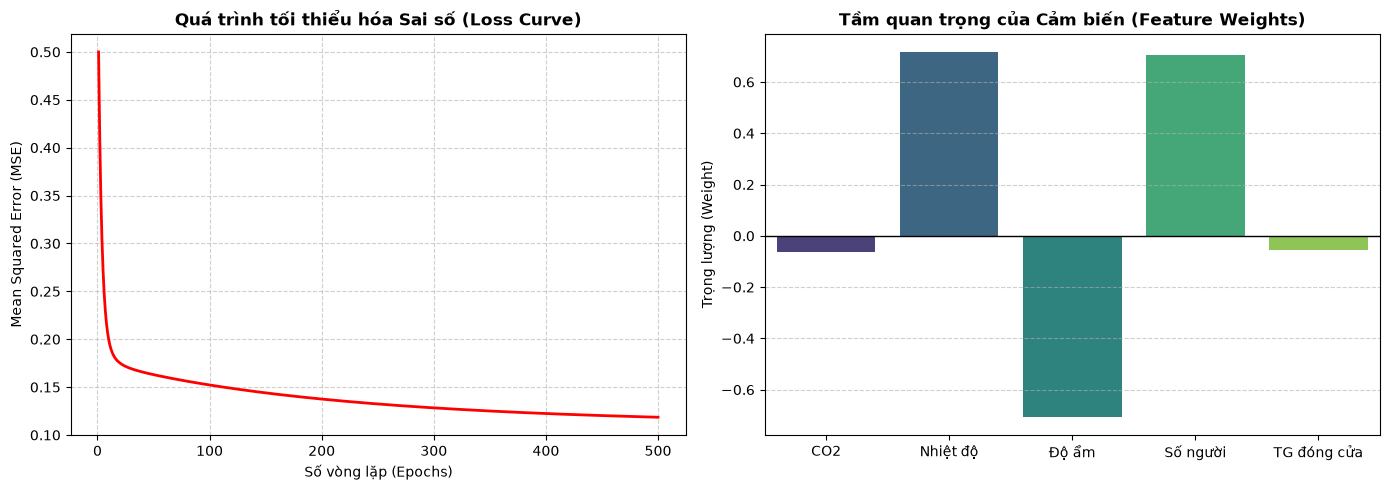

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# ... (phần code vẽ đồ thị bên dưới giữ nguyên) ...
plt.figure(figsize=(14, 5))

# Đồ thị 1: Bằng chứng Gradient Descent hoạt động (Đường cong Loss)
plt.subplot(1, 2, 1)
plt.plot(range(1, len(model.losses_) + 1), model.losses_, color='red', linewidth=2)
plt.title('Quá trình tối thiểu hóa Sai số (Loss Curve)', fontweight='bold')
plt.xlabel('Số vòng lặp (Epochs)')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, linestyle='--', alpha=0.6)

# Đồ thị 2: Trọng số của Adaline (Feature Importance)
plt.subplot(1, 2, 2)
feature_names = ['CO2', 'Nhiệt độ', 'Độ ẩm', 'Số người', 'TG đóng cửa']
sns.barplot(x=feature_names, y=model.w_, palette='viridis', hue=feature_names, legend=False)
plt.title('Tầm quan trọng của Cảm biến (Feature Weights)', fontweight='bold')
plt.ylabel('Trọng lượng (Weight)')
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()